# 01 — Разведочный анализ и генерация признаков (EDA)

**Проект:** ML-генератор торговых сигналов (Algorithmic Trading Signal Predictor).

**Цель ноутбука:** загрузить исторические котировки через Binance API (без ключей), сгенерировать финансовые признаки на основе рыночного поведения и провести первичный анализ.

**Данные:** Открытое API Binance (klines), актив BTC-USDT.
Ноутбук рассчитан на запуск из каталога `project/`.

In [1]:
import os
import sys
from pathlib import Path
import random

if Path.cwd().name == 'notebooks':
    os.chdir('..')

PROJECT_DIR = Path.cwd()
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import datetime

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

DATA_DIR = PROJECT_DIR / "data"
ART_DIR = PROJECT_DIR / "artifacts"
FIG_DIR = ART_DIR / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка исторических данных (Binance API)

Используем публичный эндпоинт Binance, который не требует API-ключей. Скачиваем дневные свечи для Биткоина (BTC/USDT).

In [2]:
print("Скачиваем котировки BTC-USDT через Binance API...")

url = "https://api.binance.com/api/v3/klines"
params = {
    "symbol": "BTCUSDT",
    "interval": "1d",
    "limit": 1000
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data, columns=[
    'timestamp', 'open', 'high', 'low', 'close', 'volume', 
    'close_time', 'quote_av', 'trades', 'tb_base_av', 'tb_quote_av', 'ignore'
])

df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df[['date', 'open', 'high', 'low', 'close', 'volume']]

for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = df[col].astype(float)

print("Размер сырого датасета:", df.shape)
df.head()

Скачиваем котировки BTC-USDT через Binance API...
Размер сырого датасета: (1000, 6)


,date,open,high,low,close,volume
0,2023-09-22,26568.08,26743.38,26468.77,26580.14,18198.22920
1,2023-09-23,26580.14,26632.81,26509.00,26575.96,9440.70260
2,2023-09-24,26575.97,26738.54,26122.08,26248.38,15706.65771
3,2023-09-25,26248.39,26446.15,25990.46,26304.81,26266.20390
4,2023-09-26,26304.80,26397.46,26088.34,26221.67,18495.35066


## 2. Генерация признаков (Feature Engineering) и Таргета

Рассчитаем скользящие средние и показатели волатильности.

In [3]:
# Целевая переменная: 1, если цена закрытия завтра ВЫШЕ цены закрытия сегодня
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

# Скользящие средние
df['sma_7'] = df['close'].rolling(window=7).mean()
df['sma_30'] = df['close'].rolling(window=30).mean()

# Волатильность
df['volatility'] = (df['high'] - df['low']) / df['open']

# относительное изменение цены за 3 дня
df['momentum_3d'] = df['close'].pct_change(periods=3)

df.dropna(inplace=True)

data_path = DATA_DIR / "trading_data.csv"
df.to_csv(data_path, index=False)
print(f"Данные сохранены в {data_path}. Итоговый размер: {df.shape}")

Данные сохранены в d:\AIE_1\project\data\trading_data.csv. Итоговый размер: (971, 11)


## 3. Разведочный анализ (EDA)

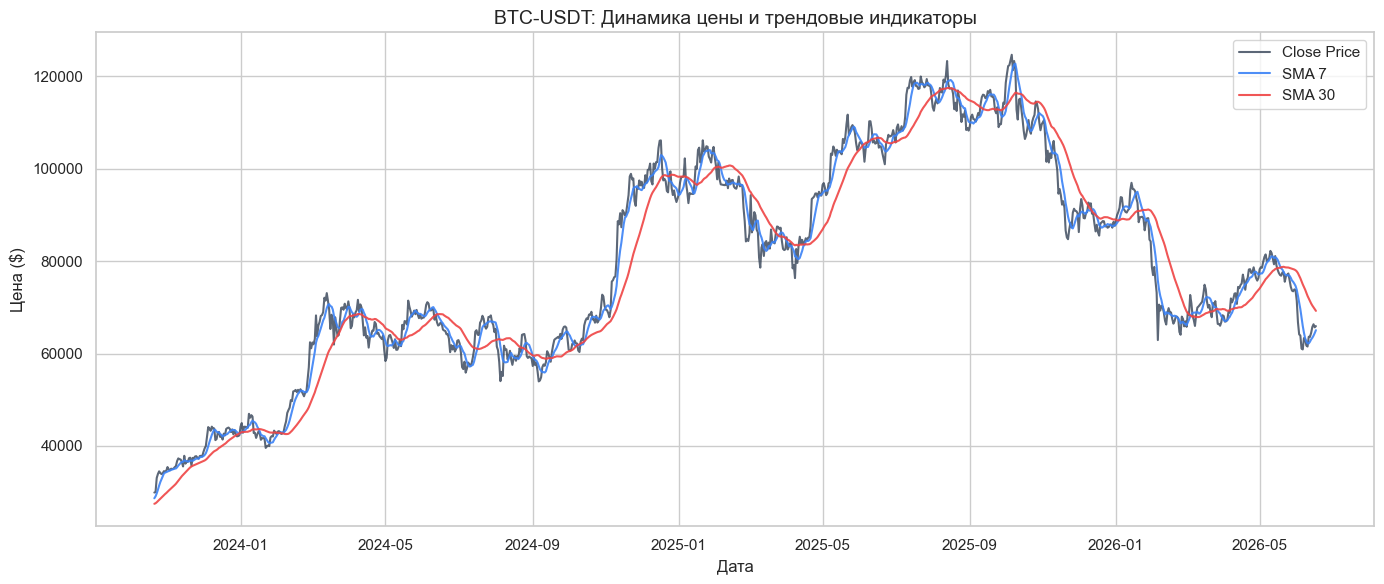

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['close'], label='Close Price', color='#334155', alpha=0.8)
plt.plot(df['date'], df['sma_7'], label='SMA 7', color='#3b82f6', alpha=0.9)
plt.plot(df['date'], df['sma_30'], label='SMA 30', color='#ef4444', alpha=0.9)
plt.title("BTC-USDT: Динамика цены и трендовые индикаторы", fontsize=14)
plt.xlabel("Дата")
plt.ylabel("Цена ($)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "price_trends.png")
plt.show()

Доля дней роста (target=1): 0.511


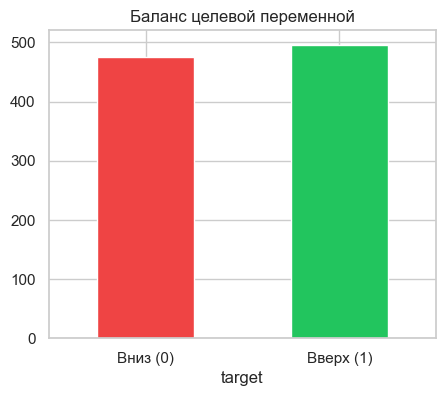

In [5]:
target_dist = df['target'].mean()
print(f"Доля дней роста (target=1): {target_dist:.3f}")

ax = df['target'].value_counts().sort_index().plot(
    kind="bar", color=["#ef4444", "#22c55e"], figsize=(5, 4)
)
ax.set_xticklabels(["Вниз (0)", "Вверх (1)"], rotation=0)
ax.set_title("Баланс целевой переменной")
plt.savefig(FIG_DIR / "target_balance.png")
plt.show()

## 4. Выводы по EDA

1. **Баланс классов:** Доля дней роста составляет 51.1%, а падения — 48.9%. Искусственная балансировка (oversampling/undersampling) при обучении не требуется.
2. **Данные готовы:** Обработанный датасет сохранен в `data/trading_data.csv` и готов для обучения Baseline-моделей.